<a href="https://colab.research.google.com/github/gustavox0/Tecnicas-Avanzdas-ML/blob/main/M7_AI3_SalazarGustavo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Style Transfer
En el pdf de la actividad se describe brevemente el método de generación de imágenes **Neural Style Transfer**. No se pretende adquirir un conocimiento profundo de este método sino utilizar la práctica para adquirir un **conocimiento intuitivo de las Redes Neuronales Convolucionales como extractores de características**.

En primer lugar, importamos PyTorch junto con otros paquetes.

In [16]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.optim as optim
import requests
from torchvision import transforms, models

## Transfer Learning: descargamos VGG19
En esta actividad vamos a utilizar el primer bloque de VGG19, que sirve para **extraer las características** de la imagen de entrada

In [17]:
# reutilizamos el modelo pre-entrenado VGG19
vgg_all = models.vgg19(pretrained=True)

# pero seleccionamos solo el primer bloque de la red que extrae features
vgg_features = vgg_all.features

# congelamos porque solo queremos optimizar la imagen target
for param in vgg_features.parameters():
    param.requires_grad_(False)

## VGG19 - Clasificador
Aunque en esta práctica solo vamos a utilizar el bloque extractor de características, podemos aprovechar para echarle un vistazo al bloque de **clasificación**.

Comprobamos que el segundo bloque, el clasificador, está compuesto por:
* capas lineales (Linear)
* funciones de activación ReLU
* capas de dropout para evitar overfitting

Si quisiéramos utilizar VGG19 como clasificador de un dataset de imágenes, deberíamos sustituir este bloque por otro similar con tantas salidas como clases haya en el dataset.

In [18]:
vgg_classifier = vgg_all.classifier
print(vgg_classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


## Pasamos modelo a GPU si está disponible

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg_features.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

## load_image
Función para cargar una imagen

In [20]:
def load_image(img_path, max_size=300, shape=None):
    ''' Load in and transform an image, making sure the image
       is <= max_size pixels in the x-y dims.'''
    if "http" in img_path:
        response = requests.get(img_path)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(img_path).convert('RGB')

    # large images will slow down processing
    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)

    if shape is not None:
        size = shape

    # VGG está normalizada con los valores de Imagenet: 0.406, 0.456, 0.485 en BGR, que invertimos en RGB.
    # En rango 0-255 seria 103.94, 116.78, 123.68 en BGR
    in_transform = transforms.Compose([
                        transforms.Resize(size),
                        transforms.ToTensor(),
                        transforms.Normalize((0.485, 0.456, 0.406),
                                             (0.229, 0.224, 0.225))])

    # con :3 eliminamos el último canal de la primera dimensión, que es el alfa e indica la transparencia
    # con unsqueeze(0) añadimos como primera dimensión el batch
    image = in_transform(image)[:3,:,:].unsqueeze(0)

    return image

## Carga de las imágenes de contenido y estilo
Además, cambiamos tamaño de la imagen de estilo a la de contenido.

In [21]:
# cargamos las imágenes de contenido y estilo
img_quinta = "https://github.com/md-lorente/Master_BD_DS/blob/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/quinta.jpeg?raw=true"
img_palamos = "https://github.com/md-lorente/Master_BD_DS/blob/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/playa_palamos.jpg"
img_soto = "https://github.com/md-lorente/Master_BD_DS/blob/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/soto_cruz_mazo.jpg?raw=true"

content = load_image(img_soto).to(device)

img_van_gogh = "https://github.com/md-lorente/Master_BD_DS/blob/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?raw=true"
img_kandinsky = "https://github.com/md-lorente/Master_BD_DS/blob/main/m%C3%B3dulo_7_aprendizaje_autom%C3%A1tico_para_machine_learning/Vassily_Kandinsky,_1913_-_Composition_7.jpg?raw=true"

# cambia tamaño de la imagen de estilo: coge los dos últimos valores de shape de la imagen de contenido
from time import sleep
error = True
while error == True:
    try:
      style = load_image(img_van_gogh, shape=content.shape[-2:]).to(device)
      error = False
    except:
      print("retry")
      sleep(1)

## im_convert
Es una función de ayuda para pasar una imagen de Tensor a numpy y poderla visualizar

In [22]:
def im_convert(tensor):

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0) # cambia ancho por alto
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)

    return image

## Veamos las imágenes de contenido y estilo

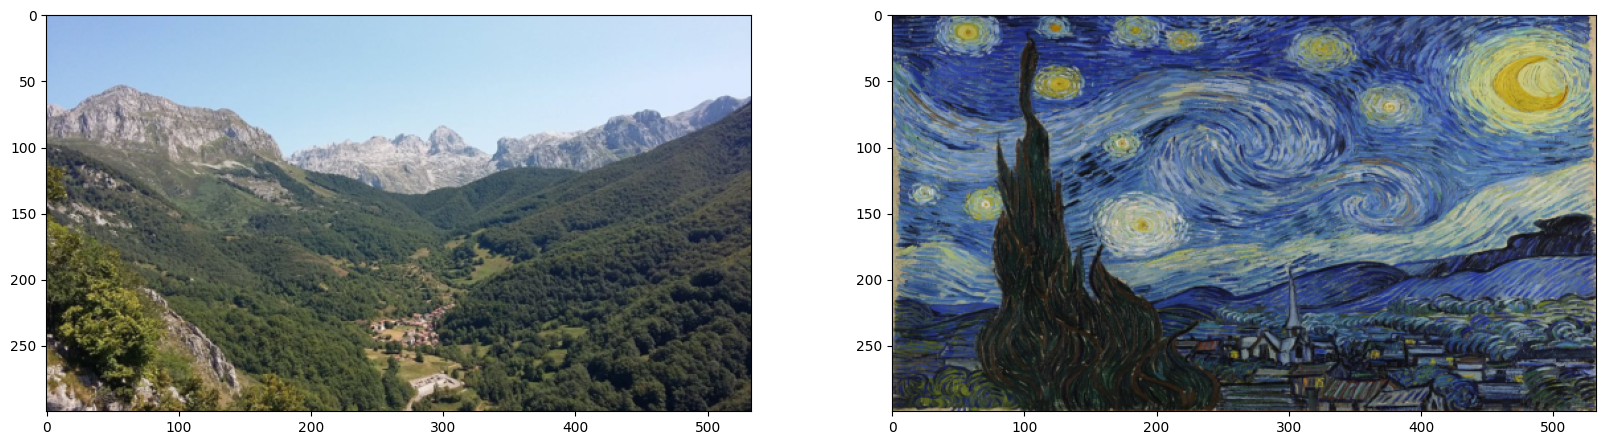

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(style))

## Capas de vgg_features
Veamos los identificadores de capas del extractor de características, vgg_features

In [24]:
print(vgg_features)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

## Extracción de características
La función get_features se utiliza para extraer las características de las imágenes de contenido y estilo.

En primer lugar, filtramos las capas que vamos a tener en cuenta para la extracción de características según se indica en el artículo de referencia. Utilizaremos varias capas para el estilo pero solo una (conv4_2) para el contenido.

A continuación, extraemos las características de la imagen para las capas seleccionadas.

In [25]:
def get_features(image, model, layers=None):

    if layers is None:
        layers = {'0': 'conv1_1',
                  '5': 'conv2_1',
                  '10': 'conv3_1',
                  '19': 'conv4_1',
                  '21': 'conv4_2',  ## contenido
                  '28': 'conv5_1'}

    features = {}
    x = image
    # model._modules es un diccionario con todas las capas
    for name, layer in model._modules.items():
        x = layer(x) # la imagen se va transformando en cada capa...
        if name in layers: # ...pero solo extraemos las características de las capas seleccionadas
            features[layers[name]] = x

    return features


## Matriz Gram
El método Style Transfer utiliza la matriz Gram o Gramian para procesar las características.

Ver https://en.wikipedia.org/wiki/Gramian_matrix

In [26]:
def gram_matrix(tensor):

    # obtenemos batch_size, depth, height y width del Tensor
    b, d, h, w = tensor.size()

    # convertimos el tensor a 2D multiplicando dimensiones entre sí
    tensor = tensor.view(b * d, h * w)

    # calculamos la matriz gram multiplicando el tensor por su transpuesto
    gram = torch.mm(tensor, tensor.t())

    return gram

## Definimos los parámetros a probar
* Definimos los pesos de las capas de estilo. Excluimos conv4_2 porque es la capa de la que extraemos el contenido.
* Definimos valores de los pesos de contenido y estilo para la función de pérdida (content_weight, style_weight).
* Definimos la tasa de aprendizaje.
* Definimos el número de iteraciones (steps)


In [27]:
style_weights = {'conv1_1': 1.,
                 'conv2_1': 0.75,
                 'conv3_1': 0.2,
                 'conv4_1': 0.2,
                 'conv5_1': 0.2}

In [28]:
#Combinacion 1
content_weight = 1  # alpha
style_weight = 1e6  # beta
learning_rate = 0.003
steps = 500 # número de iteraciones
show_every = 100 # 5 imágenes intermedias

In [ ]:
#Combinacion 2
#content_weight = 1e2  # alpha
#style_weight = 1e2  # beta
#learning_rate = 0.01
#steps = 1000 # número de iteraciones
#show_every = 200 # 5 imágenes intermedias

In [ ]:
#Combinacion 3
#content_weight = 1e2  # alpha
#style_weight = 1e-2  # beta
#learning_rate = 0.1
#steps = 2000 # número de iteraciones
#show_every = 400 # 5 imágenes intermedias

## Inicialización y entrenamiento del modelo
Tareas:
* definimos las capas del nuevo modelo
* inicializamos la imagen generada con la imagen de contenido
* definimos el optimizador
* modificamos la imagen generada mediante la función de pérdida, compuesta por la suma de la pérdida de estilo y la de contenido ponderadas

In [29]:
# extraemos características de contenido y estilo de las imágenes originales
content_features = get_features(content, vgg_features)
style_features = get_features(style, vgg_features)

# calculamos la matriz gram de cada capa de estilo
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# creamos una tercera imagen "target" que se va a ir modificando
# La inicializamos con la imagen de contenido...
# ...y le vamos cambiando el estilo
target = content.clone().requires_grad_(True).to(device)

# definimos el optimizador sobre los parámetros de la imagen target
optimizer = optim.Adam([target], lr=learning_rate)

# Defino directorio para cada combinación de parámetros
out_dir = f"output/cw{content_weight}_sw{style_weight}_lr{learning_rate}_s{steps}"

# Create the output directory if it doesn't exist
import os
os.makedirs(out_dir, exist_ok=True)


for ii in range(1, steps+1):

    # extraemos las características de la imagen generada
    target_features = get_features(target, vgg_features)

    # definimos la función de pérdida de contenido
    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)

    # definimos la función de pérdida de estilo como suma de la pérdida de cada capa
    style_loss = 0
    for layer in style_weights:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        _, d, h, w = target_feature.shape
        style_gram = style_grams[layer]
        # calculamos la "pérdida de estilo" de la capa actual y la ponderamos
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram)**2)
        # la añadimos a la pérdida de estilo
        style_loss += layer_style_loss / (d * h * w)

    # calculamos la pérdida total
    total_loss = content_weight * content_loss + style_weight * style_loss

    # actualizamos la imagen generada mediante el optimizador
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if ii % show_every == 0 or ii == steps:
        img_np = (im_convert(target) * 255).astype('uint8')
        Image.fromarray(img_np).save(f"{out_dir}/step_{ii}.jpg")
        print(f"Guardada imagen paso {ii}")
        print('Pérdida total: ', total_loss.item())

KeyboardInterrupt: 

## Evolución 5 imágenes intermedias

In [ ]:
# Mostrar las 5 imágenes intermedias en una fila 1x5
import matplotlib.image as mpimg
import os
# Lista de carpetas con combinaciones

carpetas = [
    "output/cw1_sw1000000.0_lr0.003_s500",
    "output/cw100.0_sw100.0_lr0.01_s1000",
    "output/cw100.0_sw0.01_lr0.1_s2000",
]
imagenes_por_fila = [
    ["step_100.jpg","step_200.jpg","step_300.jpg","step_400.jpg","step_500.jpg"],
    ["step_200.jpg","step_400.jpg","step_600.jpg","step_800.jpg","step_1000.jpg"],
    ["step_400.jpg","step_800.jpg","step_1200.jpg","step_1600.jpg","step_2000.jpg"],
]
# Títulos de fila
titulos_filas = [
    "cw=1, sw=1e6, lr=0.003, steps=500",
    "cw=1e2, sw=1e2, lr=0.01, steps=1000",
    "cw=1e2, sw=1e-2, lr=0.1, steps=2000"
]

# Crear figura
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(30, 16))
fig.subplots_adjust(hspace=0.3)

for idx, carpeta in enumerate(carpetas):
    for j, archivo in enumerate(imagenes_por_fila[idx]):
        ruta_imagen = os.path.join(carpeta, archivo)
        ax = axes[idx, j]
        ax.axis('off')

        try:
            img = mpimg.imread(ruta_imagen)
            ax.imshow(img)
            ax.set_title(archivo.replace(".jpg", ""), fontsize=14)  # Muestra 'step_XXX'
        except FileNotFoundError:
            ax.text(0.5, 0.5, 'Not found', ha='center', va='center', fontsize=12)

    # Título de combinación a la izquierda
    axes[idx, 0].text(
        -0.2, 0.5, titulos_filas[idx],
        ha='right', va='center', fontsize=16, fontweight='bold',
        rotation=90, transform=axes[idx, 0].transAxes
    )

plt.suptitle("Evolución por combinación de hiperparametros", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

## Veamos la imagen de contenido y la generada (final)

In [ ]:
# Última imagen de cada combinación
imagenes_finales = [
    "step_500.jpg",
    "step_1000.jpg",
    "step_2000.jpg",
]

# Convertir imágenes de contenido y estilo
content_img = im_convert(content)
style_img = im_convert(style)

# Crear figura con espacio adicional para los títulos por fila
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.subplots_adjust(hspace=0.4)

for i, (carpeta, img_name) in enumerate(zip(carpetas, imagenes_finales)):
    # Cargar imagen final
    ruta_img = os.path.join(carpeta, img_name)
    try:
        img_final = mpimg.imread(ruta_img)
    except FileNotFoundError:
        img_final = None

    # Mostrar imágenes
    axes[i, 0].imshow(content_img)
    axes[i, 0].set_title("Original", fontsize=11)
    axes[i, 1].imshow(style_img)
    axes[i, 1].set_title("Estilo", fontsize=11)

    if img_final is not None:
        axes[i, 2].imshow(img_final)
        axes[i, 2].set_title(img_name, fontsize=11)
    else:
        axes[i, 2].text(0.5, 0.5, 'Imagen no encontrada', ha='center', va='center')

    # Quitar ejes
    for j in range(3):
        axes[i, j].axis('off')

    # Título centrado por fila encima de las 3 columnas
    fig.text(
        0.5,
        0.91 - i * 0.28,
        titulos_filas[i],
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold'
    )

# Título general
plt.suptitle("Comparación: Original vs Estilo vs Imagen Final", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# Preguntas

### 1 - ¿Cuántas capas lineales contiene el clasificador de VGG19

Como puede observarse, el clasificador de vgg_all contiene 3 capas lineales. En la secuencia corresponden a (0), (3) y (6).

### 2 - ¿Cuántas clases distintas puede reconocer VGG19 en su configuración original?

Cuando cargamos vgg_classifier observamos que la última capa lineal especifica la salida de 1,000. Es decir, estas son las clases (out_features) que el modelo VGG19 reconoce por defecto.

### 3 - Indica los identificadores de capas convolucionales a continuación de capas de max pooling

Entiendo que la pregunta solicita las capas convolucionales en seguida de cada capa max pooling. De acuerdo con la salida anterior, las capas convolucionales después de max pooling son:

- (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
- (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
- (19): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
- (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

### 4 - ¿Qué influencia tienen los cambios solicitados (content_weight, style_weight, learning rate, steps) en las imágenes intermedias y en la imagen resultante?

Como puede observarse, la combinación inicial tiene un valor content_weight (1) bajo respecto al de style_weight (1e6), por lo que, a pesar de la tasa de aprendizaje es baja (0.003), la imagen resultante cambia mucho hacia las caracteísticas de la imagen de estilo.

La segunda combinación especifica el mismo valor para los parámetros conten_weigth (1e2) y style_weight (1e2). Es decir, le da una importancia similar a la imagen original y a la de estilo, por lo que la imagen resultante mandrá un balance entre las características originales y el estilo que se quiere transferir. Tambien tiene una tasa de aprendizaje (0.01) y mayor número de pasos (1000), por lo que la imágen resultante tiene mayor parecido a la imagen de estilo que cuando se utilizaron 500 steps.

Finalmente, en la tercera combinación, content_weight (1e2) es considerablemente superior a style_weight (1e-2) por lo que la imagen resultante ponderara mucho más a la imagen original. En otras palabras, la imagen resultante no tendrá cambios muy significativos de estilo. Esto aún cuando la taza de aprendizaje (0.1) y el número de pasos incrementaron considerablamente (2,000).

En resumen, la transferencia de estilo a una imagen se ve directamente afectada por el peso que se asigna a la imagen de estilo y a la imagen original. Un mayor peso a la imagen original tendrá cambios pequeños en el estilo. Un mayor peso al estilo, tendrá mayores cambios en la imagen original de acuerdo con el estilo transferido. La tasa de aprendizaje tambien es importante ya que entre mayor sea, la transferencia de estilo será más rápida.
El número de steps tambien es importante porque es el número de veces que la transferencia de estilo ocurre a la tasa de aprendizaje especificada. Si la tasa de aprendizaje es elevada, se sugiere que el número de pasos no sea elevado, pues la transferencia se realizará en pocos pasos. Asismo, cuando la tasa de aprendizaje es baja, se sugiere elevar el número de pasos para que la transferencia se complete de manera correcta, ya que el estilo se transfiere de manera más lenta. Esto último, considerando tambien los pesos de la variable original y el estilo pues, si el peso del estilo fuera muy cercano a cero (como en la tercera combinación), aun con un elevado numero de pasos y una alta tasa de aprendizaje, la imagen resultante cambiará muy poco en estilo respecto de la imagen original.
